<a href="https://colab.research.google.com/github/Ibreez16/ipl-data-analysis-pandas/blob/main/ipl_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# **Introduction**
This project performs Exploratory Data Analysis (EDA) on the IPL Matches dataset (2008–2022) using Python and Pandas.  
The objective is to analyze team performance, match venues, player achievements, and seasonal statistics.

# **Data Loading**

In [11]:
df = pd.read_csv('/content/IPL_Matches_2008_2022.csv')
df.head(3)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough


# **Data Cleaning**
Replacing old names of teams with new ones.

Delhi Daredevils ->Delhi Capitals,
Kings XI Punjab -> Punjab Kings,
Rising Pune Supergiants -> Rising Pune Supergiant

In [37]:
mapping_dict = {'Delhi Daredevils': 'Delhi Capitals', 'Kings XI Punjab': 'Punjab Kings', 'Rising Pune Supergiants' : 'Rising Pune Supergiant'}
df[['Team1', 'Team2']] = df[['Team1', 'Team2']].replace(mapping_dict)
df

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Capitals,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Punjab Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


# **Basic Exploration**

In [8]:
df.shape

(950, 20)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [13]:
df.describe()

,ID,Margin
count,9.500000e+02,932.000000
mean,8.304852e+05,17.056867
std,3.375678e+05,21.633109
min,3.359820e+05,1.000000
25%,5.012612e+05,6.000000
50%,8.297380e+05,8.000000
75%,1.175372e+06,19.000000
max,1.312200e+06,146.000000


In [9]:
df.isnull().sum()

,0
ID,0
City,51
Date,0
Season,0
MatchNumber,0
Team1,0
Team2,0
Venue,0
TossWinner,0
TossDecision,0


# **EDA**

In this section we analyze match outcomes, player performances,
and team statistics using Pandas.

# **Analysis**

Q) Which team has won the most matches in IPL history?

In [38]:
df['WinningTeam'].value_counts()

,count
WinningTeam,
Mumbai Indians,131
Chennai Super Kings,121
Kolkata Knight Riders,114
Royal Challengers Bangalore,109
Rajasthan Royals,96
Kings XI Punjab,88
Sunrisers Hyderabad,75
Delhi Daredevils,67
Delhi Capitals,36


Q) Which player has won the most Player of the Match awards?

Text(0.5, 1.0, 'Top 10 Players with Most Player of the Match Awards')

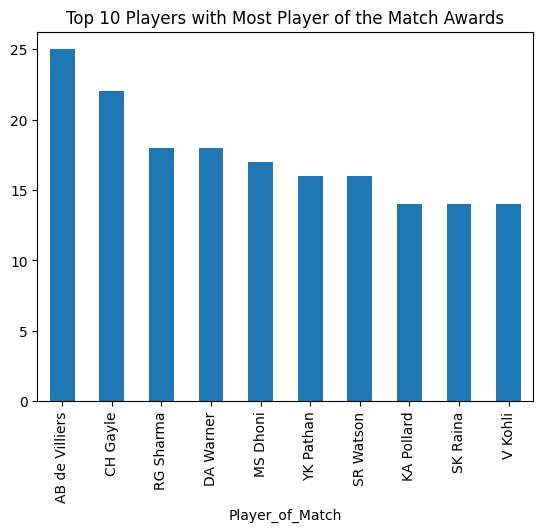

In [55]:
df['Player_of_Match'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Players with Most Player of the Match Awards")

Q) Which venue has hosted the most IPL matches?

Text(0.5, 1.0, 'Top 10 Venues which has hosted most IPL matches')

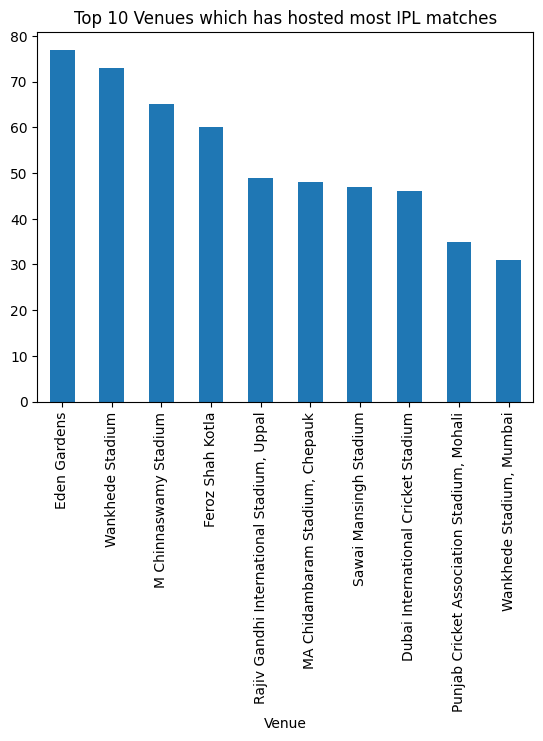

In [57]:
df['Venue'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Venues which has hosted most IPL matches")

Q) Player who got Most no. of player of the match award playing against Mumbai Indians.

In [41]:
req_column = df[((df['Team1'] == 'Mumbai Indians') | (df['Team2'] == 'Mumbai Indians')) & (df["WinningTeam"] != 'Mumbai Indians')]
req_column["Player_of_Match"].value_counts().head(1)

,count
Player_of_Match,
KL Rahul,4


Q) Team1 vs Team2 Dashbord


In [42]:
def team1_vs_team2(team1,team2):
  #mask = (((ipl_df['Team1'] == team1) & (ipl_df['Team2'] == team2)) | ((ipl_df['Team1'] == team2) & (ipl_df['Team2'] == team1)))
  mask = df.apply(lambda x: {x['Team1'], x['Team2']} == {team1, team2}, axis=1)
  mask2 = df[mask][["Team1", "Team2", "WinningTeam", "Player_of_Match"]]

  player_of_the_match = mask2["Player_of_Match"].mode()[0]

  name_of_winner = mask2["WinningTeam"].value_counts().head(1).index[0]
  name_of_loser = mask2["WinningTeam"].value_counts().tail(1).index[0]

  wins_of_winner = mask2["WinningTeam"].value_counts().head(1).values[0]
  wins_of_loser = mask2["WinningTeam"].value_counts().tail(1).values[0]

  losses_of_winner = mask2.shape[0] - wins_of_winner
  losses_of_loser = mask2.shape[0] - wins_of_loser

  dashboard = {name_of_winner : [wins_of_winner, losses_of_winner, player_of_the_match],
               name_of_loser : [wins_of_loser, losses_of_loser, player_of_the_match],
               ' ': ['Won', 'Lost', 'Player of the Match']
               }
  dashboard_df = pd.DataFrame(dashboard)
  dashboard_df.set_index(" ", inplace=True)
  display(dashboard_df)

team1_vs_team2('Kolkata Knight Riders','Mumbai Indians')


,Mumbai Indians,Kolkata Knight Riders
,,
Won,22,9
Lost,9,22
Player of the Match,RG Sharma,RG Sharma


Q) Bar chart of top 5 teams who have played maximum number of matches in the IPL.

Text(0.5, 1.0, 'Top 5 teams with Max Number of Matches Played')

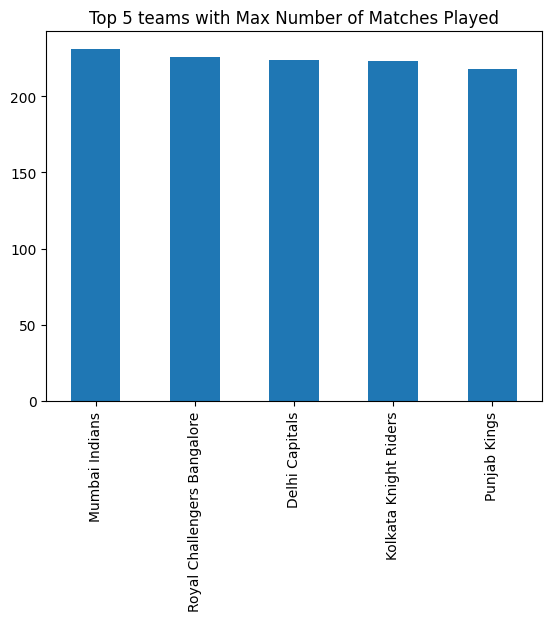

In [58]:
df[['Team1','Team2']].stack().value_counts().head(5).plot(kind='bar')
plt.title("Top 5 teams with Max Number of Matches Played")

Q)Find out the top 7 cities where the matches of Kolkata Knight Riders are played frequently and plot the result as a chart.

Text(0.5, 1.0, 'Top 7 cities where KKR played frequently')

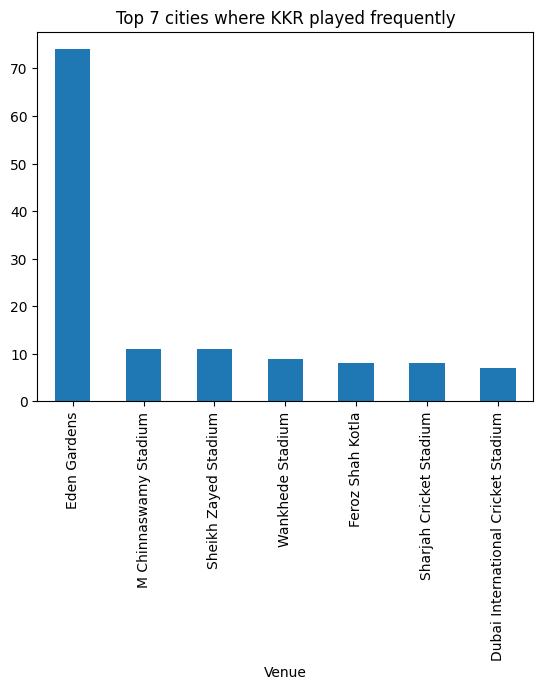

In [60]:
#ipl_df[((ipl_df['Team1'] == 'Kolkata Knight Riders') | (ipl_df['Team2'] == 'Kolkata Knight Riders'))]["Venue"].value_counts().head(7).plot(kind='bar')
df.query("Team1 == 'Kolkata Knight Riders' or Team2 == 'Kolkata Knight Riders'")["Venue"].value_counts().head(7).plot(kind='bar')
plt.title("Top 7 cities where KKR played frequently")

Q) Find out the average margin for the team Mumbai Indians for only the session 2011.

In [45]:
df[(df['Season'] == '2011') & ((df["Team1"] == "Mumbai Indians")|(df["Team2"] == "Mumbai Indians"))]["Margin"].mean()


np.float64(19.25)

Q) Make a dataframe of each team in IPL with details like - Team Name, Matches Played, Win%, Home Win%, Away Win%.

In [46]:
new_df = pd.DataFrame(df["Team1"].unique())
new_df.rename(columns={0: "Teams"}, inplace=True)

match_count = df[['Team1', 'Team2']].stack().value_counts()
new_df["Matches Played"] = new_df["Teams"].map(match_count)

wins = df["WinningTeam"].value_counts()
new_df["Wins"] = new_df["Teams"].map(wins)
new_df["Win%"] = ((new_df["Wins"]/new_df["Matches Played"])*100).round()

home_wins = df[df["Team1"] == df["WinningTeam"]]
home_wins = home_wins["Team1"].value_counts()
new_df["Home Wins"] = new_df['Teams'].map(home_wins)
new_df["Home Wins%"] = ((new_df["Home Wins"]/new_df["Matches Played"])*100).round()

away_wins = df[df["Team2"] == df["WinningTeam"]]
away_wins = away_wins["Team2"].value_counts()
new_df["Away Wins"] = new_df['Teams'].map(away_wins)
new_df["Away Wins%"] = ((new_df["Away Wins"]/new_df["Matches Played"])*100).round()
new_df

,Teams,Matches Played,Wins,Win%,Home Wins,Home Wins%,Away Wins,Away Wins%
0,Rajasthan Royals,192,96,50.0,49,26.0,47,24.0
1,Royal Challengers Bangalore,226,109,48.0,61,27.0,48,21.0
2,Sunrisers Hyderabad,152,75,49.0,36,24.0,39,26.0
3,Delhi Capitals,224,36,16.0,15,7.0,21,9.0
4,Chennai Super Kings,208,121,58.0,65,31.0,56,27.0
5,Gujarat Titans,16,12,75.0,4,25.0,8,50.0
6,Lucknow Super Giants,15,9,60.0,7,47.0,2,13.0
7,Kolkata Knight Riders,223,114,51.0,56,25.0,58,26.0
8,Punjab Kings,218,13,6.0,7,3.0,6,3.0
9,Mumbai Indians,231,131,57.0,65,28.0,66,29.0


Q) Player with most appearance in final match.

In [50]:
df["All Players"] = (df["Team1Players"] + df['Team2Players'])
no_of_players = df['All Players'].str.replace(r"[\[\]']", "", regex=True).str.split(',').explode().value_counts()
no_of_players

,count
All Players,
MS Dhoni,233
KD Karthik,229
RA Jadeja,209
SK Raina,204
KA Pollard,189
...,...
AB DindaJ Arunkumar,1
A Chopra,1
PJ SangwanS Vidyut,1


Q) IPL Point Table

In [52]:
def point_table(season):
  print(season)
  new_df = pd.DataFrame(df[df["Season"] == season])

  result_df = new_df["Team1"].unique()
  result_df = pd.DataFrame(result_df).rename(columns = {0: "Team Name"})

  match_count = new_df[['Team1', 'Team2']].stack().value_counts()
  result_df["Matches Played"] = result_df["Team Name"].map(match_count)

  wins = new_df["WinningTeam"].value_counts()
  result_df["Wins"] = result_df["Team Name"].map(wins)

  result_df["Points"] = result_df["Wins"] * 2

  result_df = result_df.set_index("Team Name")
  result_df.sort_index(inplace=True)
  result_df.sort_values('Points',ascending=False, inplace=True)

  result_df["Ranks"] = result_df["Points"].rank(ascending=False, method='first')

  result_df["Season Position"] = " "

  winner = result_df.head().index[0]
  runner = result_df.head().index[1]
  qualifier = result_df.head().index[2]
  eliminator = result_df.head().index[3]

  result_df.at[winner, 'Season Position'] = str('Winner')
  result_df.at[runner, 'Season Position'] = str('Runner')
  result_df.at[qualifier, 'Season Position'] = str('Losing Team in Qualifier2')
  result_df.at[eliminator, 'Season Position'] = str('Losing Team in Eliminator')

  return result_df


season_parameter = df["Season"].unique()
for i in season_parameter:
  display(point_table(i))


2022


,Matches Played,Wins,Points,Ranks,Season Position
Team Name,,,,,
Gujarat Titans,16,12,24,1.0,Winner
Rajasthan Royals,17,10,20,2.0,Runner
Royal Challengers Bangalore,16,9,18,3.0,Losing Team in Qualifier2
Lucknow Super Giants,15,9,18,4.0,Losing Team in Eliminator
Punjab Kings,14,7,14,5.0,
Delhi Capitals,14,7,14,6.0,
Sunrisers Hyderabad,14,6,12,7.0,
Kolkata Knight Riders,14,6,12,8.0,
Chennai Super Kings,14,4,8,9.0,


2021


,Matches Played,Wins,Points,Ranks,Season Position
Team Name,,,,,
Chennai Super Kings,16,11,22,1.0,Winner
Delhi Capitals,16,10,20,2.0,Runner
Kolkata Knight Riders,17,9,18,3.0,Losing Team in Qualifier2
Royal Challengers Bangalore,15,9,18,4.0,Losing Team in Eliminator
Mumbai Indians,14,7,14,5.0,
Punjab Kings,14,6,12,6.0,
Rajasthan Royals,14,5,10,7.0,
Sunrisers Hyderabad,14,3,6,8.0,


2020/21


...

,Matches Played,Wins,Points,Ranks,Season Position
Team Name,,,,,
Mumbai Indians,16,11.0,22.0,1.0,Winner
Chennai Super Kings,16,9.0,18.0,2.0,Runner
Deccan Chargers,16,8.0,16.0,3.0,Losing Team in Qualifier2
Royal Challengers Bangalore,16,8.0,16.0,4.0,Losing Team in Eliminator
Kolkata Knight Riders,14,7.0,14.0,5.0,
Rajasthan Royals,14,6.0,12.0,6.0,
Delhi Capitals,14,NaN,NaN,NaN,
Punjab Kings,14,NaN,NaN,NaN,


2009


,Matches Played,Wins,Points,Ranks,Season Position
Team Name,,,,,
Deccan Chargers,16,9.0,18.0,1.0,Winner
Royal Challengers Bangalore,16,9.0,18.0,2.0,Runner
Chennai Super Kings,14,8.0,16.0,3.0,Losing Team in Qualifier2
Mumbai Indians,13,5.0,10.0,4.0,Losing Team in Eliminator
Kolkata Knight Riders,13,3.0,6.0,5.0,
Delhi Capitals,15,NaN,NaN,NaN,
Punjab Kings,14,NaN,NaN,NaN,


2007/08


,Matches Played,Wins,Points,Ranks,Season Position
Team Name,,,,,
Rajasthan Royals,16,13.0,26.0,1.0,Winner
Chennai Super Kings,16,9.0,18.0,2.0,Runner
Mumbai Indians,14,7.0,14.0,3.0,Losing Team in Qualifier2
Kolkata Knight Riders,13,6.0,12.0,4.0,Losing Team in Eliminator
Royal Challengers Bangalore,14,4.0,8.0,5.0,
Deccan Chargers,14,2.0,4.0,6.0,
Delhi Capitals,14,NaN,NaN,NaN,
Punjab Kings,15,NaN,NaN,NaN,


# **Insights**


1. Mumbai Indians and Chennai Super Kings dominate the IPL in terms of total wins.

2. Certain venues such as Eden Garden host significantly more matches.

3. A small group of players dominate the Player of the Match awards.

4. Home advantage slightly increases the probability of winning matches.